In [1]:
import pickle 
import seaborn as sns
import pandas as pd
import shap
import torch
import torch.nn as nn
import numpy as np
from operator import add
from functools import reduce
from torchvision import models, transforms
from skimage import io
from torch.utils.data import Subset
from model import MultiInputModel

In [2]:
data = pd.read_csv("../data.csv")
features_name = data.iloc[:,5:].columns.values

In [3]:
data.head()

,Patient,label,photo_1,photo_2,eye_side,G,T,TS,NS,N,NI,TI,age
0,ADALCI P SILVA 00002252,1,/home/felipemarcelino/google_drive/comp_scienc...,/home/felipemarcelino/google_drive/comp_scienc...,right,60,56,74,51,58,78,54,80.0
1,ADAO A SENA 1017456,1,/home/felipemarcelino/google_drive/comp_scienc...,/home/felipemarcelino/google_drive/comp_scienc...,right,27,20,39,43,22,30,17,61.0
2,ADAO A SENA 1017456,0,/home/felipemarcelino/google_drive/comp_scienc...,/home/felipemarcelino/google_drive/comp_scienc...,left,95,62,121,107,76,121,133,61.0
3,ADAO JOSE ANDRE 01087502,0,/home/felipemarcelino/google_drive/comp_scienc...,/home/felipemarcelino/google_drive/comp_scienc...,right,102,52,136,153,63,145,152,75.0
4,ADAO JOSE ANDRE 01087502,0,/home/felipemarcelino/google_drive/comp_scienc...,/home/felipemarcelino/google_drive/comp_scienc...,left,92,50,127,143,60,115,128,75.0


In [123]:
def create_df_results(dict_results, model_name):
    val_auc_history = dict_results["fold_val_auc_history"]
    val_sensitivity_history = dict_results["fold_val_sensitivity_history"]
    val_specificity_history = dict_results["fold_val_specificity_history"]
    val_acc_history = dict_results["fold_val_acc_history"]
    flatten_list_auc = reduce(add, val_auc_history)
    flatten_list_acc = reduce(add, val_acc_history)
    flatten_list_sensitivity = reduce(add, val_sensitivity_history)
    flatten_list_specificity = reduce(add, val_specificity_history)
    df_results_auc = pd.DataFrame(flatten_list_auc, columns=["auc"])
    df_results_sen = pd.DataFrame(flatten_list_sensitivity, columns=["sensitivity"])
    df_results_spe = pd.DataFrame(flatten_list_specificity, columns=["specificity"])
    df_results_acc = pd.DataFrame(flatten_list_acc, columns=["acc"])
   
    
    df_results = pd.concat([df_results_auc, df_results_acc, df_results_sen, df_results_spe], axis=1)
    df_results["model"] = model_name
    df_results["epochs"] = list(range(50)) * 5
    
    return df_results


In [129]:
with open('../models/regnet_multi_input_k_fold.pkl', 'rb') as handle:
    dict_results_multi = pickle.load(handle)

with open('../models/regnet_single_intput_k_fold.pkl', 'rb') as handle:
    dict_results_single = pickle.load(handle)


In [103]:
dict_results.keys()

dict_keys(['fold_val_acc_history', 'fold_val_auc_history', 'fold_val_sensitivity_history', 'fold_val_specificity_history'])

In [130]:
df_results_multi = create_df_results(dict_results_multi,"multi_input")
df_results_single = create_df_results(dict_results_single,"single_input")

In [131]:
df_results_multi.head()

,auc,acc,sensitivity,specificity,model,epochs
0,0.585129,0.677632,0.372093,0.798165,multi_input,0
1,0.553552,0.743421,0.116279,0.990826,multi_input,1
2,0.549285,0.717105,0.162791,0.935780,multi_input,2
3,0.598250,0.736842,0.279070,0.917431,multi_input,3
4,0.560593,0.743421,0.139535,0.981651,multi_input,4


In [132]:
df_results_single.head()

,auc,acc,sensitivity,specificity,model,epochs
0,0.593983,0.710526,0.325581,0.862385,single_input,0
1,0.654897,0.717105,0.511628,0.798165,single_input,1
2,0.677832,0.750000,0.511628,0.844037,single_input,2
3,0.638041,0.743421,0.395349,0.880734,single_input,3
4,0.685513,0.710526,0.627907,0.743119,single_input,4


In [133]:
df_results = pd.concat([df_results_single,df_results_multi])

In [134]:
df_results.shape

(500, 6)

In [140]:
df_results

,auc,acc,sensitivity,specificity,model,epochs
0,0.593983,0.710526,0.325581,0.862385,single_input,0
1,0.654897,0.717105,0.511628,0.798165,single_input,1
2,0.677832,0.750000,0.511628,0.844037,single_input,2
3,0.638041,0.743421,0.395349,0.880734,single_input,3
4,0.685513,0.710526,0.627907,0.743119,single_input,4
...,...,...,...,...,...,...
495,0.701412,0.781457,0.489362,0.913462,multi_input,45
496,0.703457,0.768212,0.531915,0.875000,multi_input,46
497,0.741919,0.821192,0.531915,0.951923,multi_input,47
498,0.710004,0.801325,0.468085,0.951923,multi_input,48


<AxesSubplot:xlabel='epochs', ylabel='auc'>

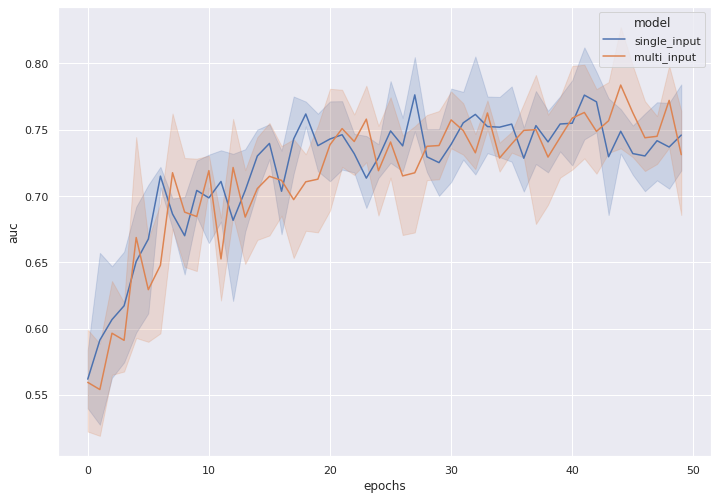

In [141]:
sns.lineplot(data=df_results, x="epochs", y="auc", hue="model")

# Shap

In [19]:
n_classes = 2
ft_size = 8
model_reg = models.regnet_y_800mf(pretrained=True)
features = nn.Sequential(*list(model_reg.children()))[:-1]
in_features = 784
output_tab = 3

#num_ftrs = model.fc.in_features
#model.fc = nn.Linear(num_ftrs, n_classes)

model = MultiInputModel(features, ft_size, output_tab, in_features, n_classes)


In [20]:
model.load_state_dict(torch.load("../models/regnet_multi_input_1.pth"))

<All keys matched successfully>

In [21]:
dataloader_val = torch.load("../models/k_fold_val_dataloader_regnet_multi_input_1.pth")

In [22]:
len(dataloader_val.dataset)

152

In [23]:
num_train_examples = 152
background = Subset(dataloader_val.dataset, np.arange(num_train_examples))

In [24]:
features_back_imgs = []
features_back_tab = []
for i in range(len(background)):
    features_back_imgs.append(background[i][0])
    features_back_tab.append(background[i][1])

In [69]:
sample_train__img_shap = features_back_imgs[:100]
sample_test__img_shap =  features_back_imgs[100:]
sample_train__tab_shap = features_back_tab[:100]
sample_test__tab_shap = features_back_tab[100:]

In [70]:
sample_train__img_shap[0].shape

torch.Size([3, 224, 224])

In [71]:
features_back_tab[0].shape

torch.Size([8])

In [72]:
np.stack(sample_train__img_shap).shape

(100, 3, 224, 224)

In [73]:
np.stack(sample_train__tab_shap).shape

(100, 8)

In [74]:
np.stack(sample_test__tab_shap).shape

(52, 8)

# Try both

In [75]:
explainer_multi = shap.DeepExplainer(model, [torch.from_numpy(np.stack(sample_train__img_shap)), 
                                                    torch.from_numpy(np.stack(sample_train__tab_shap))])

In [76]:
from tqdm import tqdm
shap_list = []
for i in tqdm(range(len(sample_test__img_shap))):
    img = torch.from_numpy(np.stack(sample_test__img_shap[i]))
    tab = torch.from_numpy(np.stack(sample_test__tab_shap[i]))
    img = img[None,:]
    tab = tab[None,:]
    single_shaps_values = explainer_multi.shap_values([img,tab])
    shap_list.append(single_shaps_values)
    


100%|████████████████████████████████████████████████| 52/52 [27:50<00:00, 32.13s/it]


In [84]:
# 0 img
# 1 tab
tab_shap_list_pos = []
img_shap_list_pos = []
tab_shap_list_neg = []
img_shap_list_neg = []

for i in range(len(shap_list)):
    tab_shap_list_neg.append(shap_list[i][0][1])
    img_shap_list_neg.append(shap_list[i][0][0])      
    tab_shap_list_pos.append(shap_list[i][0][1])
    img_shap_list_pos.append(shap_list[i][0][0])     
    

In [85]:
tab_shap_values_neg = np.concatenate(tab_shap_list_neg, axis=0)
img_shap_values_neg = np.concatenate(img_shap_list_neg, axis=0)
tab_shap_values_pos = np.concatenate(tab_shap_list_pos, axis=0)
img_shap_values_pos = np.concatenate(img_shap_list_pos, axis=0)

In [86]:
shap_values_tab = np.concatenate([tab_shap_list_neg, tab_shap_list_pos],axis=1)
shap_values_img = np.concatenate([img_shap_list_neg, img_shap_list_pos],axis=1)

In [87]:
swaped_shap_values = np.swapaxes(shap_values_tab,0,1)

In [88]:
shap_values_tab_list = [swaped_shap_values[0],swaped_shap_values[1]]

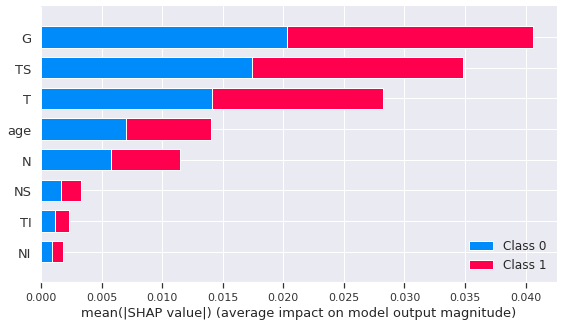

In [93]:
shap.summary_plot(shap_values_tab_list, np.stack(sample_test__tab_shap), features_name)

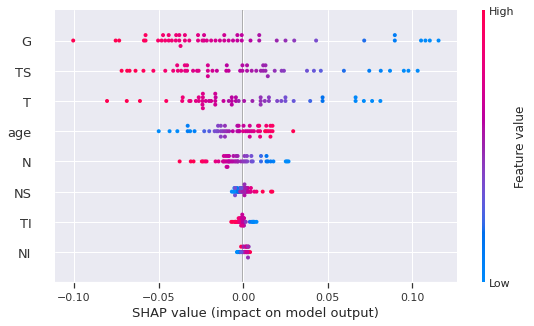

In [90]:
shap.summary_plot(-1 * (swaped_shap_values[0] + swaped_shap_values[1]), np.stack(sample_test__tab_shap), features_name)